# Bridge drug-response prediction benchmark (#5)

**Question.** Given baseline expression and a drug screen, can a frozen representation predict measured IC50 for a held-out cell line? This report does not predict a post-treatment transcriptome.

The final BulkFormer publication reports mean PCC 0.373. Its exact final folds, readout, drug grouping, and mean-PCC aggregation were not released, so that number is shown only as a literature reference. The local comparison uses identical observations, held-out-cell-line folds, and ridge-readout rules for every representation.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display
RESULTS = Path('results')
audit = json.loads((RESULTS/'dataset_audit.json').read_text())
audit

{'all_response_cells_in_expression': True,
 'auc_summary': {'25%': 0.8110872810216815,
  '50%': 0.9318555397673008,
  '75%': 0.974121805856417,
  'count': 212299.0,
  'max': 0.9995518764712854,
  'mean': 0.8577541656214982,
  'min': 0.0059955003287364,
  'std': 0.17461616698234042},
 'bridge_symbol_overlap': 15130,
 'bulkformer_symbol_overlap': 18916,
 'cell_lines': 700,
 'dataset_version_drug_screens': 355,
 'dataset_versions': {'GDSC1': 116895, 'GDSC2': 95404},
 'duplicate_cell_drug_id_rows': 65546,
 'duplicate_cell_version_drug_rows': 0,
 'exact_duplicate_rows': 0,
 'expression_duplicate_cell_ids': 0,
 'expression_genes': 19098,
 'expression_max': 17.223230361938477,
 'expression_min': -1.841268539428711,
 'expression_missing_values': 0,
 'expression_negative_values': 1782260,
 'expression_rows': 700,
 'gdsc_drug_ids': 295,
 'ic50_summary': {'25%': 0.8103532219536431,
  '50%': 2.7286285890693343,
  '75%': 4.230792997802965,
  'count': 212299.0,
  'max': 12.354551771505358,
  'mean':

## Cohort, endpoint, and split

The final released tables contain 700 DepMap cell lines, 212,299 response observations, 295 GDSC drug IDs, 255 PubChem compounds, and 355 dataset-version-specific screens. IC50 is used unchanged. Five deterministic folds hold out complete cell lines; no response from a test cell line enters readout training. PCA is refit inside every fold. Drug identity is represented by a separate linear output head for each GDSC-version-specific screen, so unseen-drug generalization is neither attempted nor claimed.

In [2]:
results = pd.read_csv(RESULTS/'primary_results.csv')
results.sort_values('mean_pcc', ascending=False).round(3)

,representation,mean_pcc,median_pcc,mean_scc,rmse,evaluable_drugs
0,bridge_45.6m,0.448,0.461,0.424,1.235,355
2,bulkformer_50m,0.438,0.450,0.414,1.238,355
1,bulkformer_147m,0.436,0.452,0.416,1.244,355
3,pca128_bridge,0.284,0.273,0.432,1.587,355
6,raw_expression,0.196,0.156,0.440,2.257,355
4,pca_128,0.088,0.065,0.424,3.499,355
5,pca_512,0.031,0.021,0.348,4.002,355


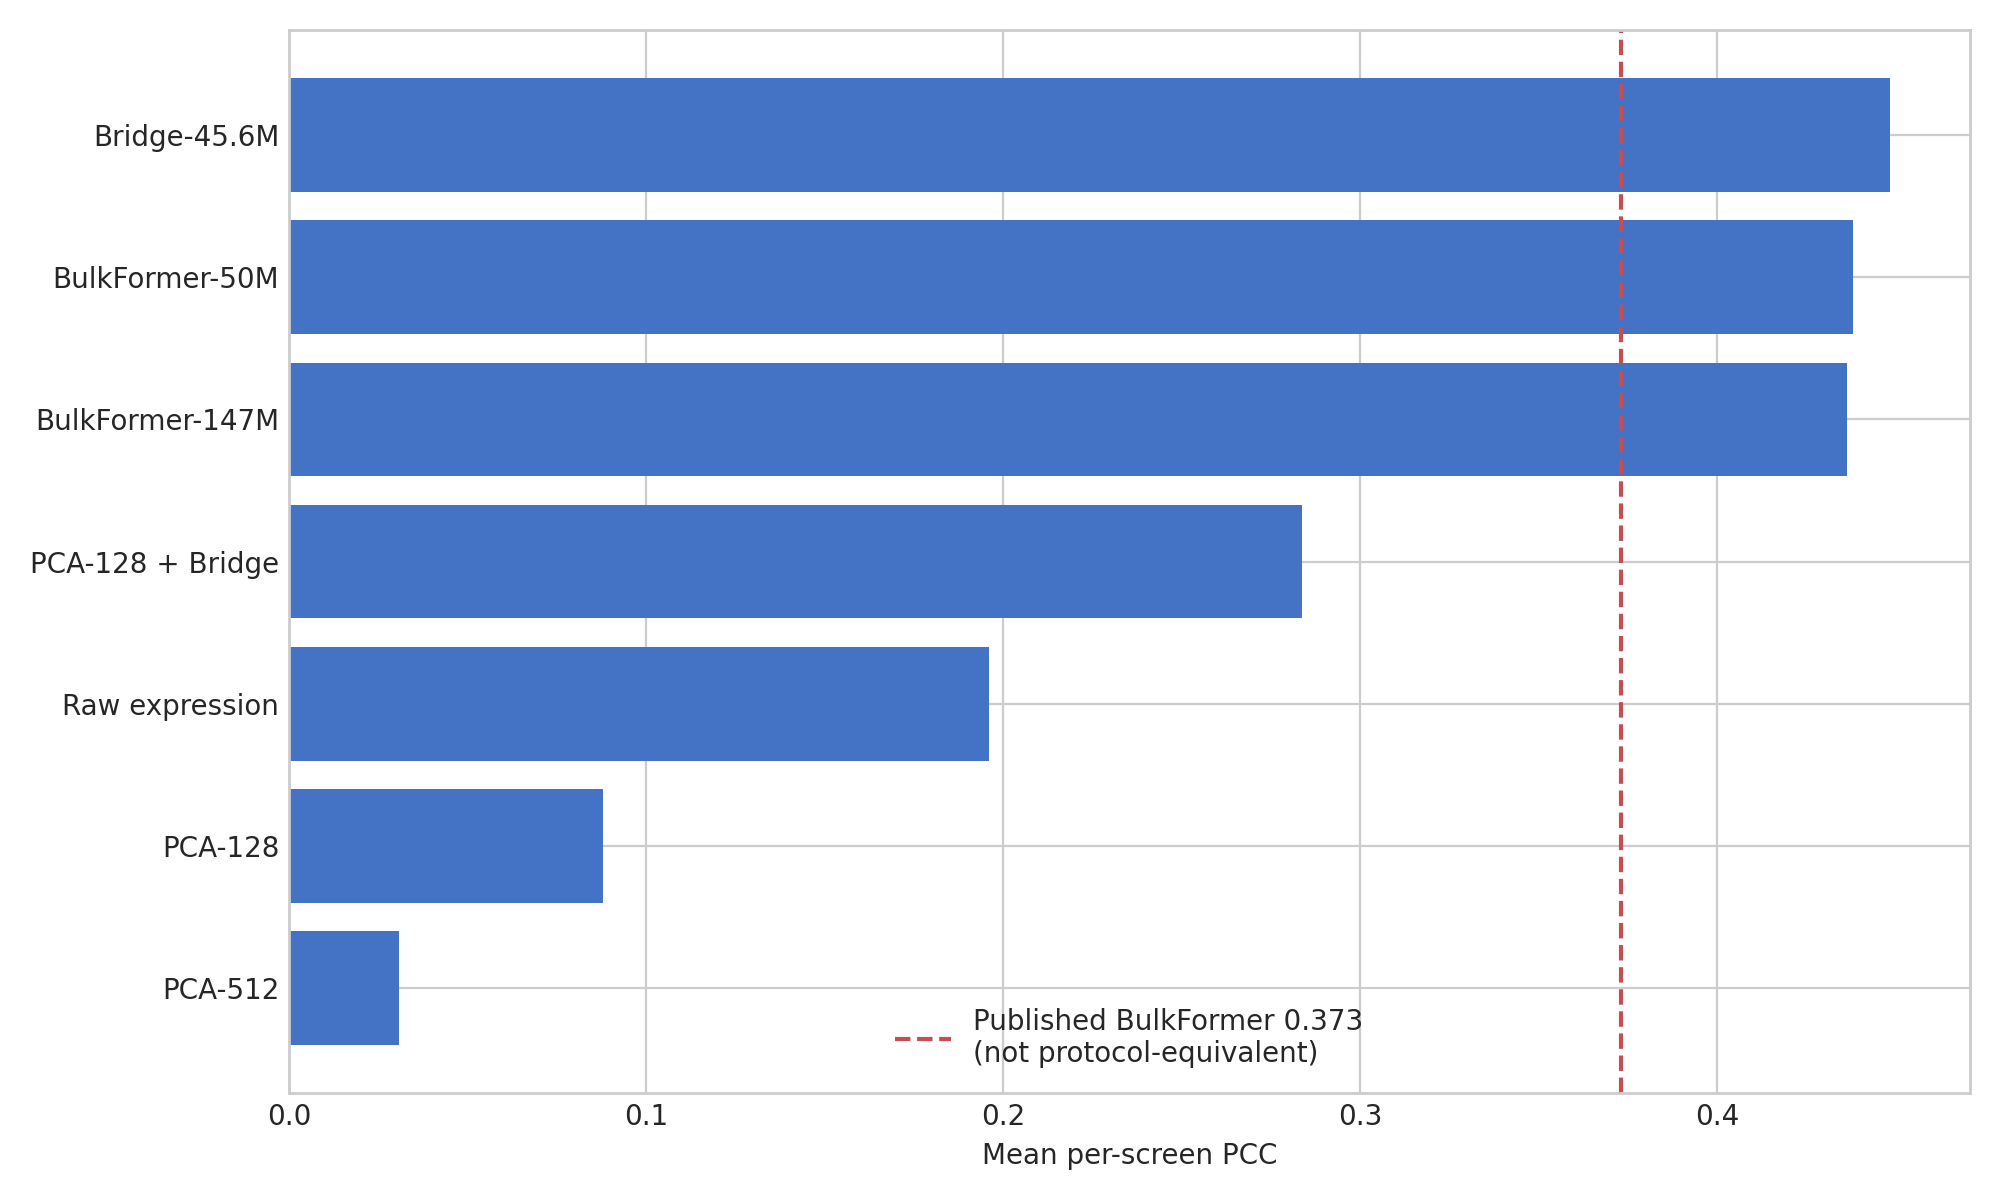

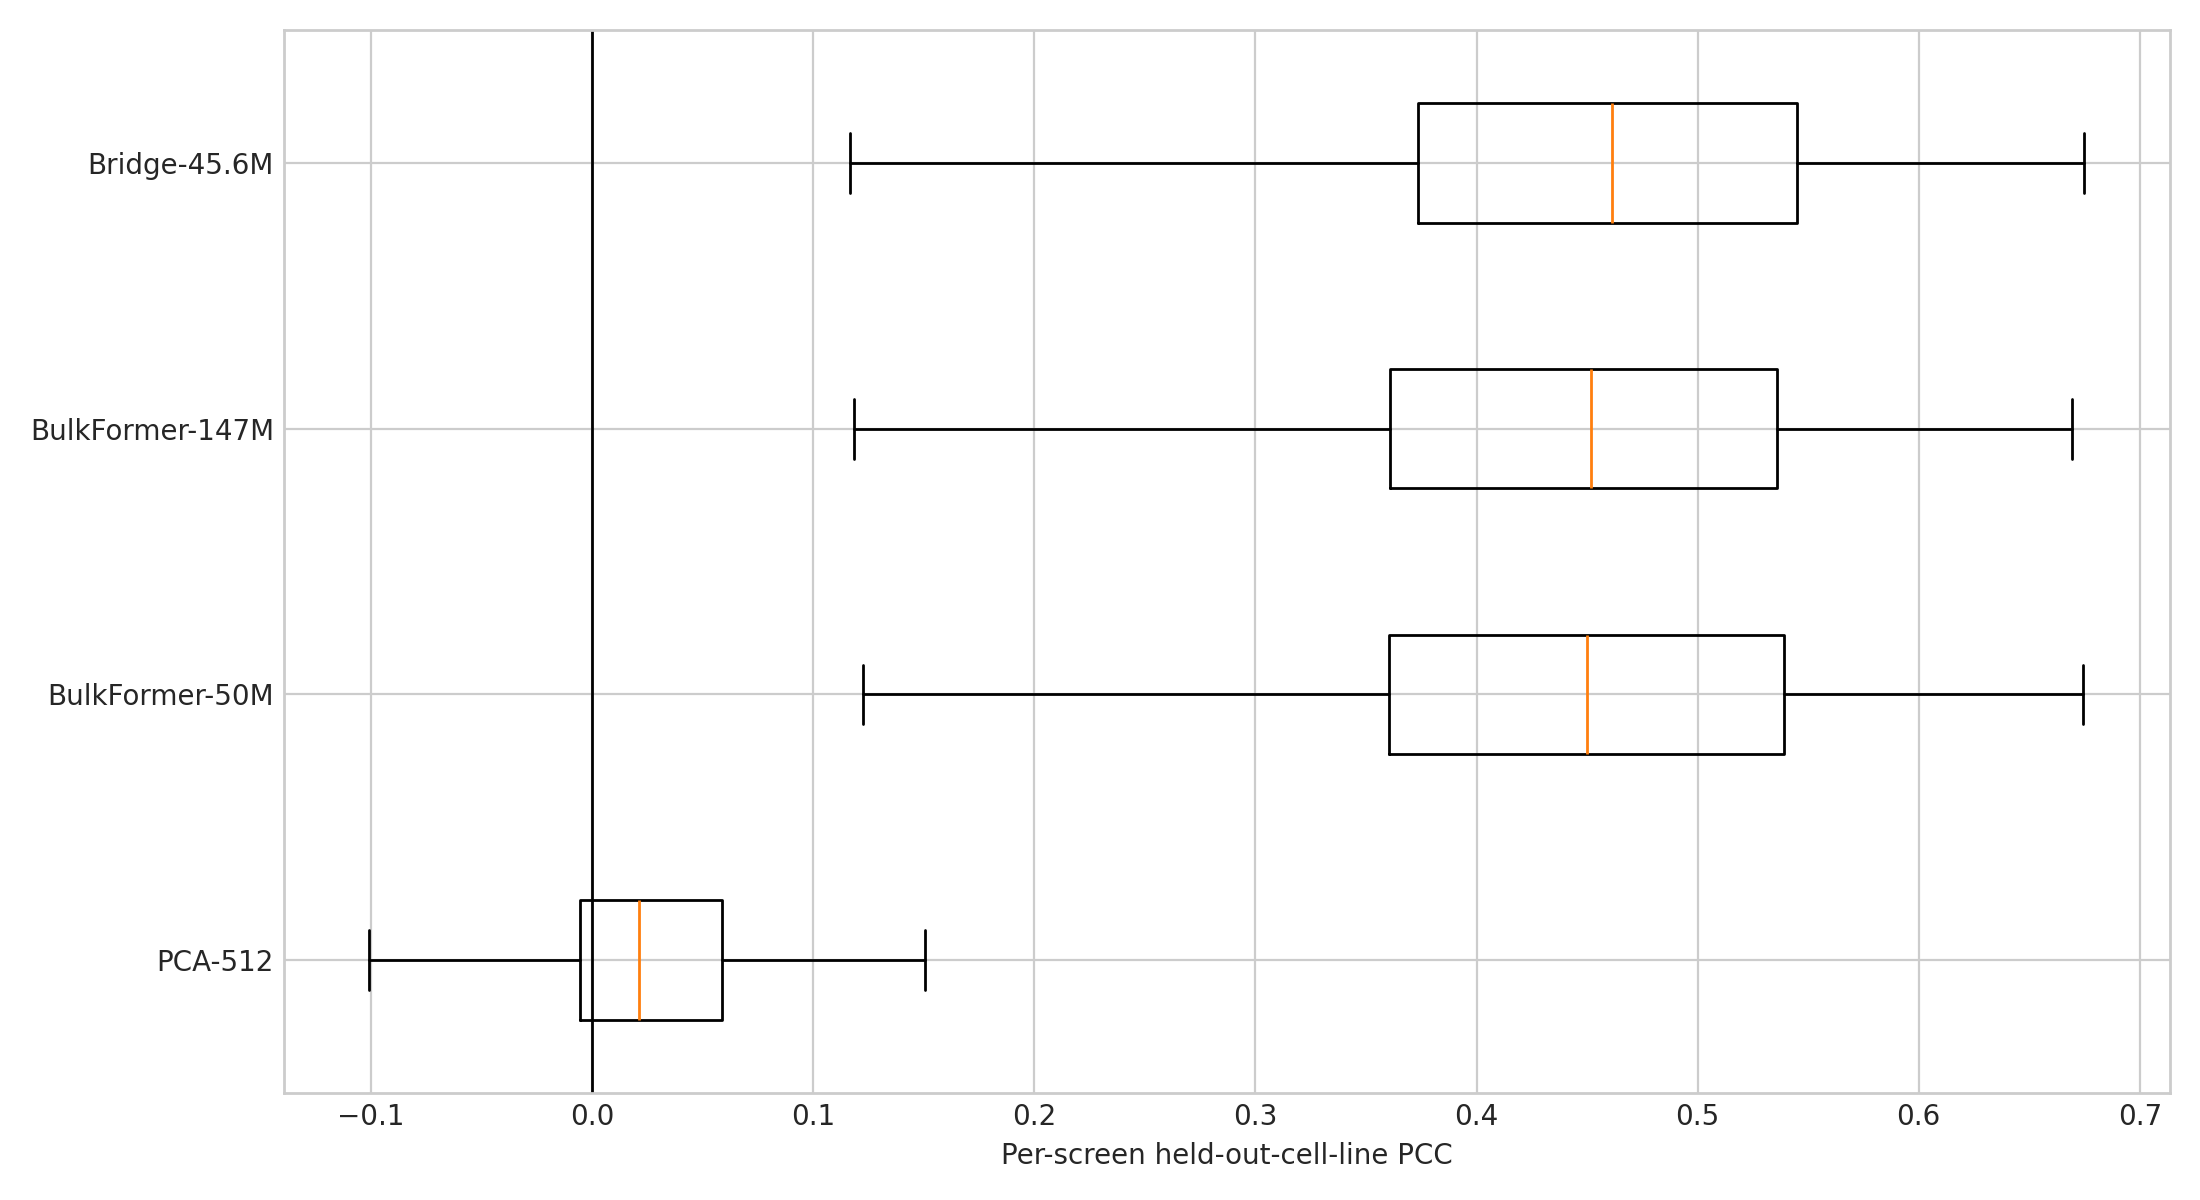

In [3]:
display(Image(filename=str(RESULTS/'primary_mean_pcc.png')))
display(Image(filename=str(RESULTS/'per_drug_pcc_distribution.png')))

## Paired comparisons and complementarity

Differences below are paired by screen. Bootstrap intervals resample screens, not individual cell-line observations.

In [4]:
pd.read_csv(RESULTS/'paired_comparisons.csv').round(3)

,left,right,n_drugs,mean_delta_pcc,median_delta_pcc,ci95_low,ci95_high,fraction_left_better
0,bridge_45.6m,pca_512,355,0.418,0.429,0.404,0.431,1.000
1,bridge_45.6m,bulkformer_50m,355,0.010,0.009,0.008,0.012,0.718
2,bridge_45.6m,bulkformer_147m,355,0.012,0.012,0.009,0.015,0.746
3,pca128_bridge,pca_128,355,0.196,0.196,0.184,0.208,0.994


In [5]:
pd.read_csv(RESULTS/'variance_controls.csv').round(3)

,comparison,spearman_delta_vs_response_variance,spearman_delta_vs_observation_count
0,bridge_45.6m-raw_expression,0.054,0.197
1,bridge_45.6m-pca_128,0.049,0.366
2,bridge_45.6m-pca_512,0.164,0.396
3,bridge_45.6m-bulkformer_50m,0.156,-0.060
4,bridge_45.6m-bulkformer_147m,-0.061,-0.055


## Conclusion and limitations

Under this common held-out-cell-line linear-readout protocol, frozen Bridge has the highest mean per-screen PCC and exceeds both locally evaluated BulkFormer checkpoints on most screens. PCA-128 + Bridge contains substantially more predictive signal than PCA-128 alone, but it does not outperform Bridge alone, so this run does not establish useful complementarity beyond Bridge. Raw expression and PCA results are sensitive to regularization and the released matrix's undocumented processing.

The main limitations are decisive: the final BulkFormer downstream code and split definition are unavailable; the public processed expression contains negative values and cannot be converted exactly back to natural log1p(TPM); drug-screen identity is modeled with separate heads and cannot extrapolate to unseen drugs; and ARCHS4 pretraining exposure is unresolved because no GEO/SRA sample accessions are released. Therefore local scores are controlled comparisons on a transparent new protocol, not reproductions of published 0.373.